# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yousefelshazly/FlyRankMachineLearning/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

I chose a Decision Tree for its simplicity and interpretability. It can be kept shallow, which makes the splits easy to read and understand — this helps explain why a page was flagged, which matters for the next steps. What I'm predicting is: given a page's GSC performance in March 2026, will it continue declining in April 2026? A page is labelled declining (1) if its average GSC position in April is worse than in March, and stable or improving pages are labelled (0). This fits the GSC lane because the features are columns that are readily available at decision time — impressions, clicks, CTR, and position trend — with no future data and no GA4 dependency. The model learns which combinations of these signals actually predict continued decline, which goes beyond what a single hand-written rule can do.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*


The feature window is March 2026 — this is the data the model learns from. The label window is April 2026 — this is what we're trying to predict. A page is labelled declining (1) if its average GSC position in April is worse than in March, and stable or improving (0) otherwise.

The split is grouped by client, not random. This is important because a random split would allow the same client's pages to appear in both training and test sets, which would let the model learn client-specific patterns instead of general signals that work across all clients. FlyRank always onboards new clients, so the model must generalize beyond clients it has already seen.

The train/test ratio is 80/20 — 80% of clients go into training, the remaining 20% into test.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

Precision was chosen as the primary metric because FlyRank has limited resources — flagging pages that actually need a refresh matters more than overall accuracy. The model uses a Decision Tree with max depth 4, keeping it shallow and interpretable. Compared to a dummy baseline that flags every page as declining (precision: 0.622), the Decision Tree achieves a precision of 0.694 — a 7.2 percentage point improvement. This is a modest but honest gain, showing the model learned real signal from March GSC data rather than just predicting the majority class. There is room for improvement in future iterations.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import duckdb
import pandas as pd
from google.colab import userdata

token = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{token}')")
rel = "hf://datasets/FlyRank/internship-warehouse"

# Load March 2026 — feature window
march = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        AVG(gsc_avg_position) as avg_position_march,
        AVG(gsc_impressions) as avg_impressions_march,
        ROUND(SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0), 4) as ctr_march,
        AVG(gsc_clicks) as avg_clicks_march
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
""").df()

print("March shape:", march.shape)
print(march.head(3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March shape: (176738, 6)
            client_hash_id           content_hash_id  avg_position_march  \
0  client_62f4a7e64f5e0096  content_39d7361b4945d504            4.074107   
1  client_62f4a7e64f5e0096  content_c03ecafd4c999f15            8.240351   
2  client_62f4a7e64f5e0096  content_e689bc511192751a            6.015432   

   avg_impressions_march  ctr_march  avg_clicks_march  
0               3.208333      0.000          0.000000  
1             349.967742      0.002          0.709677  
2               2.259259      0.000          0.000000  


In [6]:
# Load April 2026 — label window
april = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        AVG(gsc_avg_position) as avg_position_april,
        AVG(gsc_impressions) as avg_impressions_april,
        ROUND(SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0), 4) as ctr_april,
        AVG(gsc_clicks) as avg_clicks_april
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-04/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
""").df()

print("april shape:", april.shape)
print(april.head(3))

april shape: (194760, 6)
            client_hash_id           content_hash_id  avg_position_april  \
0  client_62f4a7e64f5e0096  content_35d979572550dd7f           15.778483   
1  client_62f4a7e64f5e0096  content_d95e1739253d6a65           28.641513   
2  client_62f4a7e64f5e0096  content_405cc2e0475690e9           45.544314   

   avg_impressions_april  ctr_april  avg_clicks_april  
0              39.333333        0.0               0.0  
1               7.000000        0.0               0.0  
2               8.300000        0.0               0.0  


In [7]:
# Merge March features with April data — inner join keeps only pages in both months
df = march.merge(april, on=['client_hash_id', 'content_hash_id'], how='inner')

print("Merged shape:", df.shape)
print("Pages in March only:", len(march) - len(df))
print("Pages in April only:", len(april) - len(df))
print(df.head(3))

Merged shape: (158549, 10)
Pages in March only: 18189
Pages in April only: 36211
            client_hash_id           content_hash_id  avg_position_march  \
0  client_62f4a7e64f5e0096  content_39d7361b4945d504            4.074107   
1  client_62f4a7e64f5e0096  content_c03ecafd4c999f15            8.240351   
2  client_62f4a7e64f5e0096  content_e689bc511192751a            6.015432   

   avg_impressions_march  ctr_march  avg_clicks_march  avg_position_april  \
0               3.208333      0.000          0.000000            5.968421   
1             349.967742      0.002          0.709677            8.860571   
2               2.259259      0.000          0.000000            6.051903   

   avg_impressions_april  ctr_april  avg_clicks_april  
0               1.421053     0.0000          0.000000  
1             537.366667     0.0014          0.766667  
2               3.681818     0.0123          0.045455  


In [9]:
df['label'] = (df['avg_position_april'] > df['avg_position_march']).astype(int)

In [10]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True).round(3))

label
1    102554
0     55995
Name: count, dtype: int64
label
1    0.647
0    0.353
Name: proportion, dtype: float64


In [11]:
feature_cols = ['avg_position_march', 'avg_impressions_march', 'ctr_march', 'avg_clicks_march']

X = df[feature_cols]
y = df['label']

print("Features shape:", X.shape)
print("Label shape:", y.shape)

Features shape: (158549, 4)
Label shape: (158549,)


In [12]:
import numpy as np

# Get unique clients
clients = df['client_hash_id'].unique()
print(f"Total clients: {len(clients)}")

# Shuffle and split 80/20
np.random.seed(42)
np.random.shuffle(clients)

split_idx = int(len(clients) * 0.8)
train_clients = clients[:split_idx]
test_clients = clients[split_idx:]

# Split the data
train_mask = df['client_hash_id'].isin(train_clients)
test_mask = df['client_hash_id'].isin(test_clients)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train clients: {len(train_clients)}, rows: {len(X_train)}")
print(f"Test clients: {len(test_clients)}, rows: {len(X_test)}")

Total clients: 46
Train clients: 36, rows: 137575
Test clients: 10, rows: 20974


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score

# Train Decision Tree
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")

Accuracy:  0.681
Precision: 0.694


In [14]:
import numpy as np

# Dummy baseline — predict declining for everything
y_dummy = np.ones(len(y_test), dtype=int)
dummy_precision = precision_score(y_test, y_dummy)
dummy_accuracy = accuracy_score(y_test, y_dummy)

# Comparison table
print("=" * 40)
print(f"{'Model':<25} {'Accuracy':>8} {'Precision':>10}")
print("=" * 40)
print(f"{'Dummy (all declining)':<25} {dummy_accuracy:>8.3f} {dummy_precision:>10.3f}")
print(f"{'Decision Tree':<25} {accuracy:>8.3f} {precision:>10.3f}")
print("=" * 40)

Model                     Accuracy  Precision
Dummy (all declining)        0.622      0.622
Decision Tree                0.681      0.694


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*
My model being the decision tree split on average position , the first split is on average position, on position 6.99, which shows that the tree gives an answer based on how high does the page rank, which is wrong, a page going from position 35 to 40 does not need to be weighed high, while a page moving from 3 to 4 could mean alot. This is the honest error where the tree hyperfixated on position and not on other features.

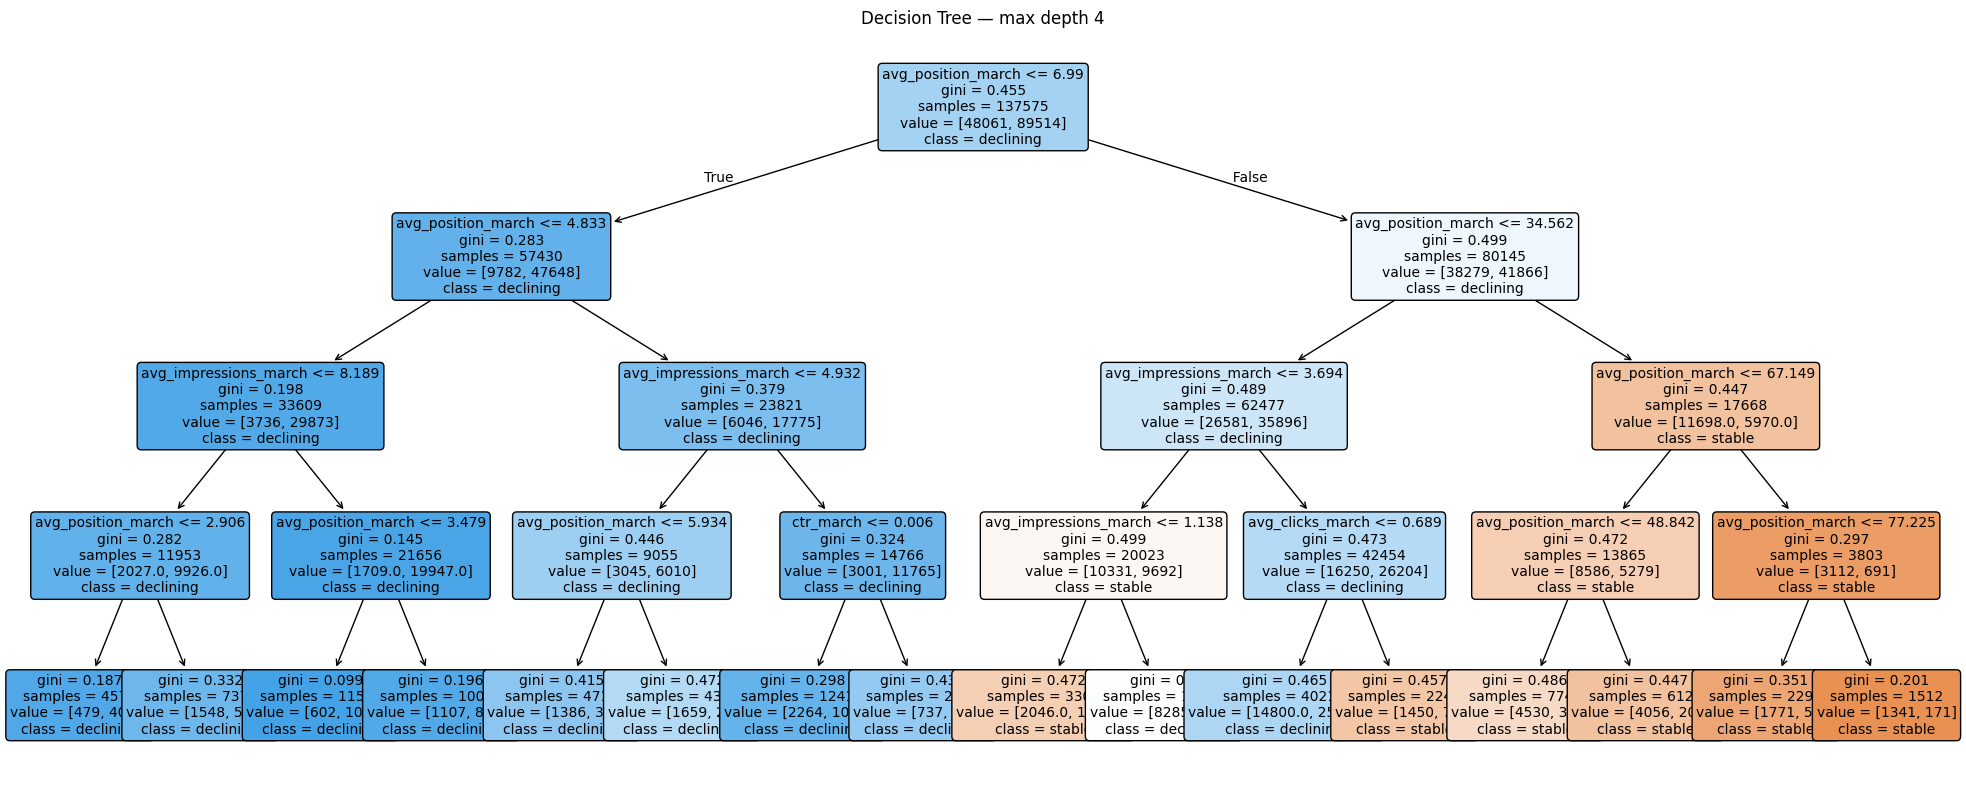

In [17]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
plot_tree(clf, feature_names=feature_cols, class_names=['stable', 'declining'],
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree — max depth 4")
plt.tight_layout()
plt.savefig('work/outputs/decision_tree.png')
plt.show()


In [16]:
os.makedirs('work/outputs', exist_ok=True)
plt.savefig('work/outputs/decision_tree.png')

<Figure size 640x480 with 0 Axes>

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.